In [1]:
'''libraries'''
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#math
import numpy as np

#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c

#Usefull
from tqdm.notebook import tqdm
import pynucastro as pyna
#%matplotlib widget

In [2]:

df_1 = pd.read_csv("Runs/Run_1/toplist.dat",sep="\s{2,}",skiprows=2,header=None, engine='python')
#df_2=pd.read_csv("Runs/run2/generated_energy.dat",sep="\s{2,}",skiprows=2,header=None,engine='python')
df_3=pd.read_csv("Runs/Run_3/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_4=pd.read_csv("Runs/Run4/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_5=pd.read_csv("Runs/Run_zhou/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_6=pd.read_csv("Runs/Run_tian/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_7=pd.read_csv("Runs/Run_zhoureddi/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_8=pd.read_csv("Runs/Run_tianreddi/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_9=pd.read_csv("Runs/Run_tian_NHMF_9/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_10=pd.read_csv("Runs/Run_tian_ROYER_10/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_11=pd.read_csv("Runs/Run_zhou_NMHF_11/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_12=pd.read_csv("Runs/Run_zhou_ROYER_12/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_13=pd.read_csv("Runs/Run_zhou_SONG_13/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_14=pd.read_csv("Runs/Run_tian_SONG_3_14/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
#df_15=pd.read_csv("Runs/Run_tian_NHMF_3/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')

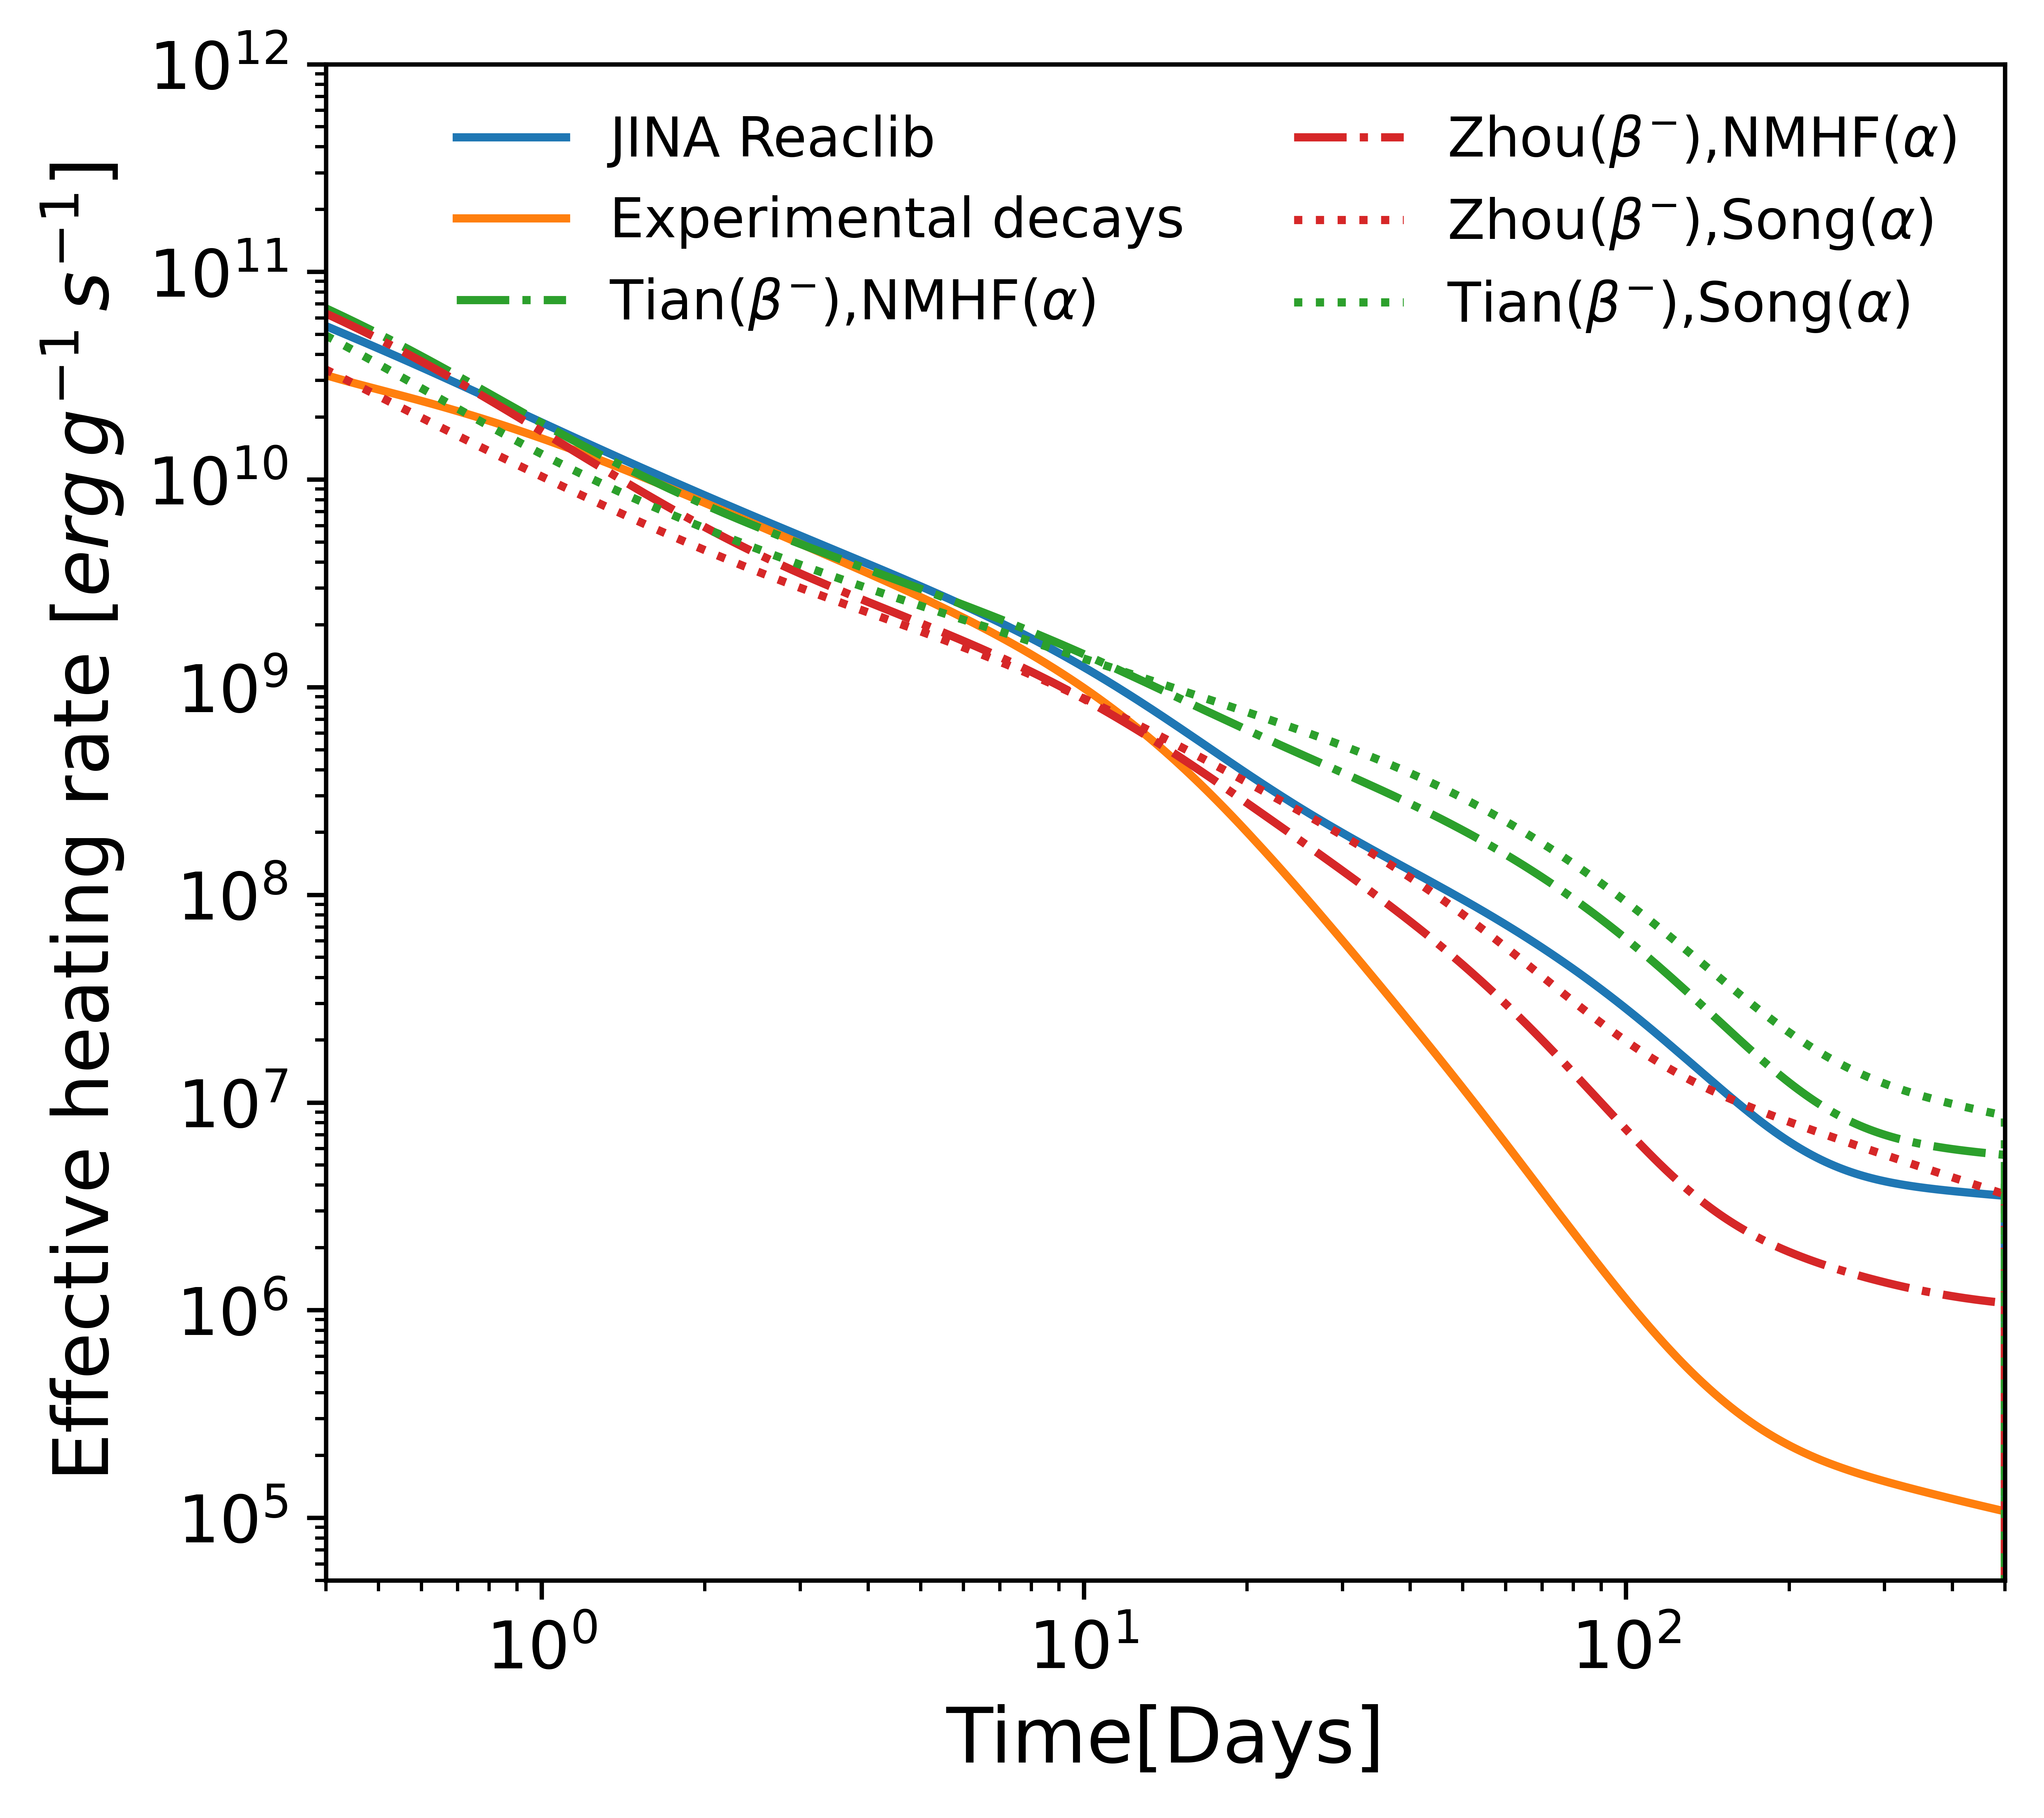

In [6]:
'''Preliminar figures'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(5.5,5), dpi=1200)
plt.plot(df_1[0]/(24*60*60),df_1[1],linestyle='-',label='JINA Reaclib')
#plt.plot(df_2[0]/(24*60*60),df_2[1],linestyle=':',label='Run_2')
plt.plot(df_3[0]/(24*60*60),df_3[1],linestyle='-',label='Experimental decays')
#plt.plot(df_4[0]/(24*60*60),df_4[1],linestyle='--',label='Run_4')
#plt.plot(df_5[0]/(24*60*60),df_5[1],linestyle='-',label='Run_5')
#plt.plot(df_6[0]/(24*60*60),df_6[1],linestyle='-',label='Run_6')
#plt.plot(df_7[0]/(24*60*60),df_7[1],linestyle='-',label='Run_7')
#plt.plot(df_8[0]/(24*60*60),df_8[1],linestyle='-',label='Run_8')
plt.plot(df_9[0]/(24*60*60),df_9[1],linestyle='-.',label=r'Tian($\beta^{-}$),NMHF($\alpha$)')
#plt.plot(df_10[0]/(24*60*60),df_10[1],linestyle=':',label='Run_10',color='cyan')
plt.plot(df_11[0]/(24*60*60),df_11[1],linestyle='-.',label=r'Zhou($\beta^{-}$),NMHF($\alpha$)')
#plt.plot(df_12[0]/(24*60*60),df_12[1],linestyle=':',label='Run_12',color='purple')
plt.plot(df_13[0]/(24*60*60),df_13[1],linestyle=':',label=r'Zhou($\beta^{-}$),Song($\alpha$)',color='C3')
plt.plot(df_14[0]/(24*60*60),df_14[1],linestyle=':',label=r'Tian($\beta^{-}$),Song($\alpha$)',color='C2')
#plt.plot(df_14[0]/(24*60*60),df_14[1],linestyle=':',label='Run_143')
#plt.plot(df_15[0]/(24*60*60),df_15[1],linestyle=':',label='Run_15')
#plt.plot(df[0]/(24*60*60),df[12]+df[32])
#plt.plot(df_1[0]/(24*60*60),df_1[12]+df_1[32],linestyle=':')
#plt.plot(df[0]/(24*60*60),df[13]+df[32])
#plt.plot(df_1[0]/(24*60*60),df_1[13]+df_1[32],linestyle=':')
#plt.plot(df[0]/(24*60*60),df[14]+df[32])
#plt.plot(df_1[0]/(24*60*60),df_1[14]+df_1[32],linestyle=':')
#plt.plot(df[0]/(24*60*60),df[15]+df[32])
#plt.plot(df_1[0]/(24*60*60),df_1[15]+df_1[32],linestyle=':')
#plt.plot(df[0],-df[32])
#plt.plot(df[0],df[14])
#plt.plot(df[0],df[15])

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Time[Days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=10)
plt.ylim(5e4,1e12)
plt.xlim(0.4,500)
plt.savefig("Heating_runs", bbox_inches="tight")


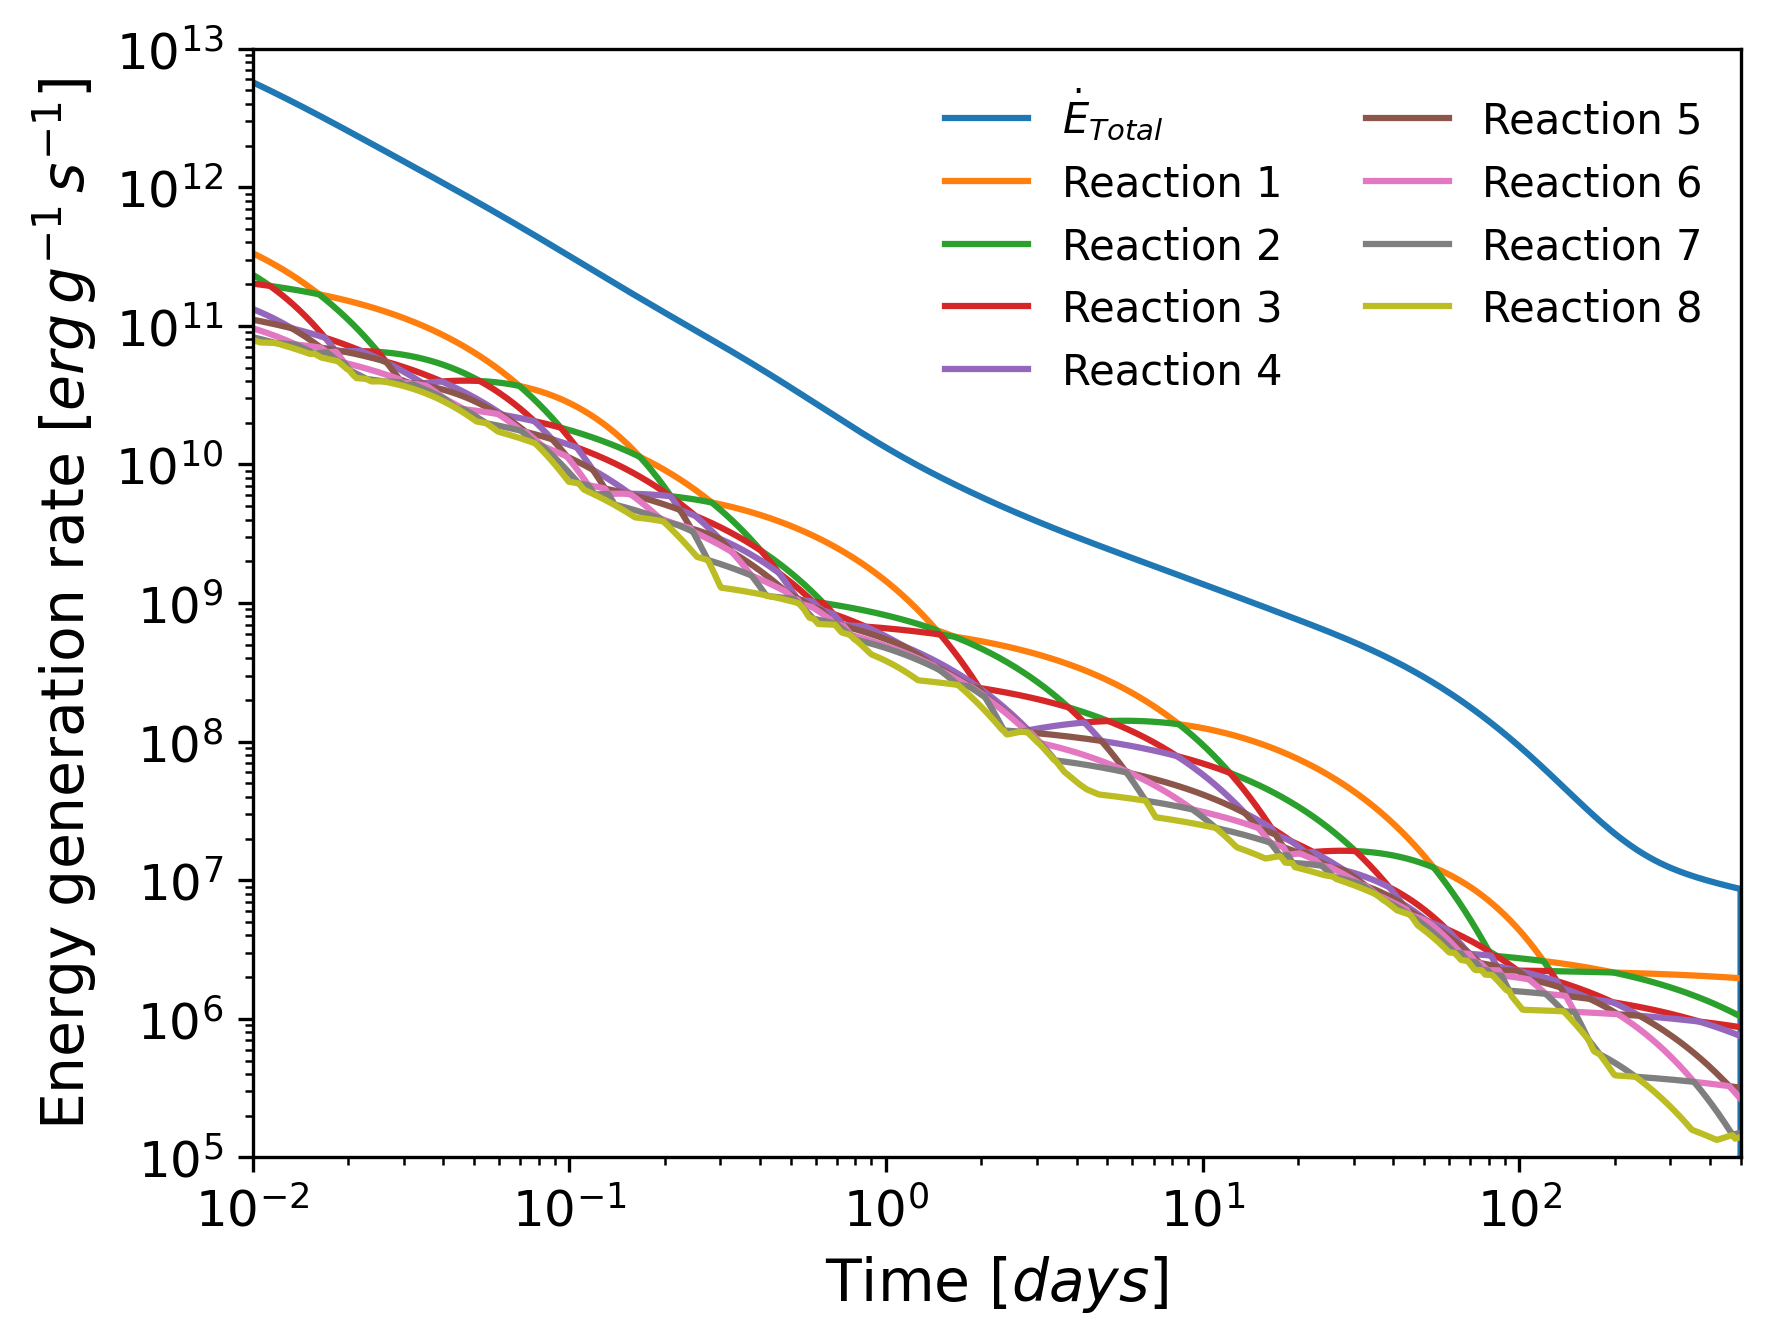

In [4]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.figure(dpi=300)
plt.plot(df_14[0]/(24*60*60),df_14[1],label=r'$\dot E_{Total}$')
#plt.plot(df_1_[0],df_1_[53],label='iso1')
plt.plot(df_14[0]/(24*60*60),df_14[12],label='Reaction 1')
plt.plot(df_14[0]/(24*60*60),df_14[13],label='Reaction 2')
plt.plot(df_14[0]/(24*60*60),df_14[14],label='Reaction 3')
plt.plot(df_14[0]/(24*60*60),df_14[15],label='Reaction 4')
plt.plot(df_14[0]/(24*60*60),df_14[16],label='Reaction 5')
plt.plot(df_14[0]/(24*60*60),df_14[17],label='Reaction 6')
plt.plot(df_14[0]/(24*60*60),df_14[18],label='Reaction 7')
plt.plot(df_14[0]/(24*60*60),df_14[19],label='Reaction 8')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'Energy generation rate $[erg\,g^{-1}\,s^{-1}]$')
plt.xlabel(r'Time $[days]$')
plt.xlim(left=0.01,right=500)
plt.ylim(1e5,1e13)
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=10)
plt.savefig('Comparison_run1_WinNet_Cheng.pdf')